In [18]:
import pandas as pd
from utils import classify_question

In [19]:
# Load all queries from the full dataset, then left-merge gold SQL where available
full_df = pd.read_json("spider2-snow.jsonl", lines=True)
gold_df = pd.read_csv("spider2snow_gold_sql.csv")[["instance_id", "sql_query"]]
orig_df = full_df.merge(gold_df, on="instance_id", how="left")
orig_df = orig_df.rename(columns={"instruction": "query"})
print(f"Total queries: {len(orig_df)}, with gold SQL: {orig_df['sql_query'].notna().sum()}")

Total queries: 547, with gold SQL: 120


query_type
Stateless               505
Stateful_No_Incident     38
Incident                  4
Name: count, dtype: int64
query_type
Stateless               92.321755
Stateful_No_Incident     6.946984
Incident                 0.731261
Name: count, dtype: float64


<Axes: xlabel='query_type'>

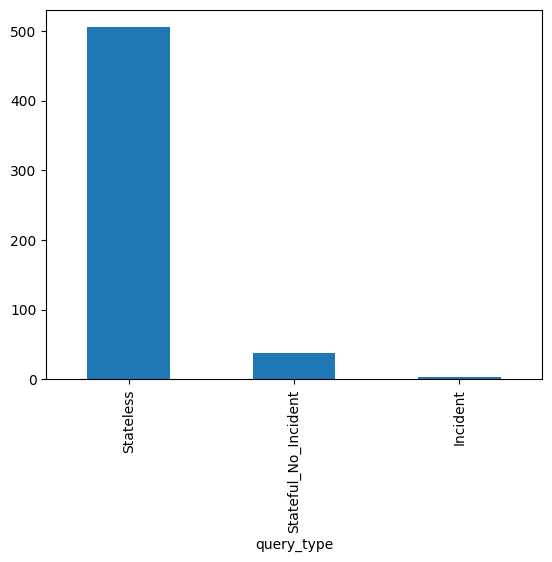

In [20]:
orig_df["query_type"] = orig_df.apply(
    lambda row: classify_question(row["query"], row["sql_query"] if pd.notna(row.get("sql_query")) else None), axis=1
)
print(orig_df["query_type"].value_counts())
print((orig_df["query_type"].value_counts() / len(orig_df)) * 100)
orig_df["query_type"].value_counts().plot(kind="bar")

In [4]:
inc_qs = orig_df[orig_df["query_type"] == "Incident"]["query"].tolist()
print(inc_qs)

['In the Iowa Liquor Sales dataset, starting from January 1, 2022 through the last fully completed month, which two liquor categories, each contributing an average of at least 1% to the monthly sales volume over at least 24 months of available data, have the lowest Pearson correlation coefficient when comparing their monthly percentages of total liquor sales across those months, and what are their names?', 'Using the \'nlst\' collection\'s CT images, calculate and compare two separate metrics: 1) The average series size in MiB for the top 3 patients with the highest slice interval difference tolerance (defined as the difference between the maximum and minimum unique slice intervals across all their series), and 2) The average series size in MiB for the top 3 patients with the highest exposure difference (defined as the difference between the maximum and minimum unique exposure values across all their series). For each patient, calculate the series size by summing the instance sizes of 

In [5]:
st_qs = orig_df[orig_df["query_type"] == "Stateful_No_Incident"]["query"].tolist()
print(st_qs)

['What was the percentage change in post-market close prices for the Magnificent 7 tech companies from January 1 to June 30, 2024?', "Can you list the top 5 months from August 2022 to November 2023 where the profit from Facebook-sourced completed orders showed the largest month-over-month increase? Calculate profit as sales minus costs, group by delivery month, and include only orders created between August 2022 and November 2023. Compare each month's profit to its previous month to find the largest increases.", "Identify the top five CT scan series by size (in MiB), including their SeriesInstanceUID, series number, patient ID, and series size. These series must be from the CT modality and not part of the 'nlst' collection. Exclude any series where the ImageType is classified as 'LOCALIZER' or where the TransferSyntaxUID is either '1.2.840.10008.1.2.4.70' or '1.2.840.10008.1.2.4.51' (i.e., JPEG compressed). The selected series must have consistent slice intervals, exposure levels, imag

In [11]:
orig_df.to_csv("spider2snow_data_classified.csv", index=False)